In [10]:
import pandas as pd
import numpy as np

In [5]:
tissue_data = pd.read_csv(r'PR80_30\tissue_data_imputed_30_renamed.csv')
plasma_data = pd.read_csv(r'PR80_30\plasma_data_imputed_30_renamed.csv')

In [7]:
plasma_data.columns

Index(['Genes', 'Sample 60', 'Sample 65', 'Sample 18', 'Sample 59',
       'Sample 42', 'Sample 30', 'Sample 31', 'Sample 77', 'Sample 32',
       'Sample 7', 'Sample 55', 'Sample 76', 'Sample 28', 'Sample 72',
       'Sample 88', 'Sample 11', 'Sample 64', 'Sample 25', 'Sample 78',
       'Sample 83', 'Sample 70', 'Sample 90', 'Sample 45', 'Sample 85',
       'Sample 17', 'Sample 22', 'Sample 57', 'Sample 66', 'Sample 38',
       'Sample 82', 'Sample 39', 'Sample 61', 'Sample 16', 'Sample 23',
       'Sample 24', 'Sample 87', 'Sample 73', 'Sample 15', 'Sample 49',
       'Sample 75', 'Sample 79', 'Sample 34', 'Sample 1', 'Sample 36',
       'Sample 29', 'Sample 5', 'Sample 86', 'Sample 52', 'Sample 12',
       'Sample 20', 'Sample 51', 'Sample 48'],
      dtype='str')

In [8]:
tissue_data = tissue_data.drop(columns = ['Unnamed: 0'])

In [11]:
assert np.all(tissue_data.columns == plasma_data.columns)

patients = tissue_data.columns

In [13]:
print(tissue_data['Genes'])

0              A1BG
1               A2M
2              AAAS
3              AACS
4             AAGAB
           ...     
6622    cRAP-CSN1S2
6623      cRAP-CSN2
6624      cRAP-CSN3
6625     cRAP-KRT15
6626      cRAP-SRPP
Name: Genes, Length: 6627, dtype: str


In [14]:
common_proteins = [protein for protein in tissue_data['Genes'].values if protein in plasma_data['Genes'].values]
print(len(common_proteins))

1416


In [15]:
tissue_shared = tissue_data.loc[tissue_data['Genes'].isin(common_proteins)]
plasma_shared = plasma_data.loc[plasma_data['Genes'].isin(common_proteins)]
print(tissue_shared.shape)
print(plasma_shared.shape)

(1416, 53)
(1416, 53)


In [21]:
print(tissue_shared.iloc[:,1:].head())

    Sample 60  Sample 65  Sample 18  Sample 59  Sample 42  Sample 30  \
0    3.377788   3.369656   3.414243   3.654232   3.466397   3.560979   
1    3.574198   3.492541   3.515855   3.811213   3.570228   3.675715   
38   3.113760   3.174530   3.089162   3.132881   3.216487   3.173729   
41   3.114876   3.282155   3.139912   2.861150   3.355573   3.391043   
48   3.088989   3.166603   3.003878   3.091466   3.180566   2.947220   

    Sample 31  Sample 77  Sample 32  Sample 7  ...  Sample 1  Sample 36  \
0    3.411005   3.333807   3.491348  3.237286  ...  3.246045   3.290469   
1    3.506992   3.509530   3.804737  3.457776  ...  3.526674   3.478921   
38   3.273096   3.232238   2.959608  2.995690  ...  3.145114   3.177402   
41   3.448289   3.471313   3.072649  3.154413  ...  3.303148   3.279756   
48   3.275087   3.157957   2.905002  3.003788  ...  3.186230   3.226233   

    Sample 29  Sample 5  Sample 86  Sample 52  Sample 12  Sample 20  \
0    3.471365  3.517356   3.233607   3.306147

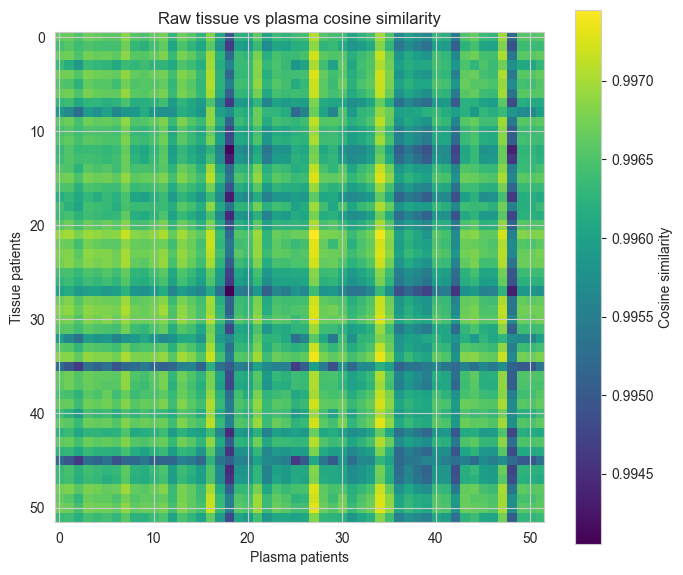

Mean positive similarity : 0.996
Mean negative similarity : 0.996
Retrieval accuracy: 0.019


In [22]:
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

X_tissue = tissue_shared.iloc[:,1:].T.values
X_plasma = plasma_shared.iloc[:,1:].T.values

# L2-normalize each sample
X_tissue = normalize(X_tissue)
X_plasma = normalize(X_plasma)

# -----------------------------
# Cosine similarity matrix
# -----------------------------
similarity = cosine_similarity(X_tissue, X_plasma)

plt.figure(figsize=(7,6))
plt.imshow(similarity, cmap="viridis")
plt.colorbar(label="Cosine similarity")
plt.title("Raw tissue vs plasma cosine similarity")
plt.xlabel("Plasma patients")
plt.ylabel("Tissue patients")
plt.tight_layout()
plt.show()

# -----------------------------
# Statistics
# -----------------------------
positive = np.diag(similarity)

mask = ~np.eye(similarity.shape[0], dtype=bool)
negative = similarity[mask]

print(f"Mean positive similarity : {positive.mean():.3f}")
print(f"Mean negative similarity : {negative.mean():.3f}")

# -----------------------------
# Retrieval accuracy
# -----------------------------
predicted = similarity.argmax(axis=1)
true = np.arange(len(predicted))

accuracy = (predicted == true).mean()

print(f"Retrieval accuracy: {accuracy:.3f}")

In [23]:
ranks = []

for i in range(similarity.shape[0]):
    order = np.argsort(similarity[i])[::-1]
    rank = np.where(order == i)[0][0] + 1
    ranks.append(rank)

print(f"Mean rank: {np.mean(ranks):.2f}")
print(f"Median rank: {np.median(ranks):.2f}")
print(f"Top-5 accuracy: {np.mean(np.array(ranks) <= 5):.3f}")

Mean rank: 24.83
Median rank: 23.00
Top-5 accuracy: 0.115
